In [1]:
import os

import anndata
import mplscience
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scanpy as sc
import scipy
import squidpy as sq
import seaborn as sns

import sys

### Extended Data Figure 7h 

In [2]:
SAMPLE="P10_T2"

adata = sq.read.visium(f"../../../../stanford_mac_backup/kptc_spatial/data/DeZuani/{SAMPLE}/", counts_file=f"{SAMPLE}-filtered_feature_bc_matrix.h5")
adata.var_names_make_unique()
adata

/orcd/data/ki/001/lab/jones/mgjones/miniconda3/envs/spatial-tracer/lib/python3.11/site-packages/anndata/_core/anndata.py:1825: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")
/orcd/data/ki/001/lab/jones/mgjones/miniconda3/envs/spatial-tracer/lib/python3.11/site-packages/anndata/_core/anndata.py:1825: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


AnnData object with n_obs × n_vars = 1986 × 36601
    obs: 'in_tissue', 'array_row', 'array_col'
    var: 'gene_ids', 'feature_types', 'genome'
    uns: 'spatial'
    obsm: 'spatial'

In [3]:
sc.pp.normalize_total(adata, target_sum=1e6)
sc.pp.log1p(adata)

/tmp/ipykernel_507746/3278942760.py:5: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(adata, color=genes, ncols=4, frameon=False, cmap='Reds', show=False)


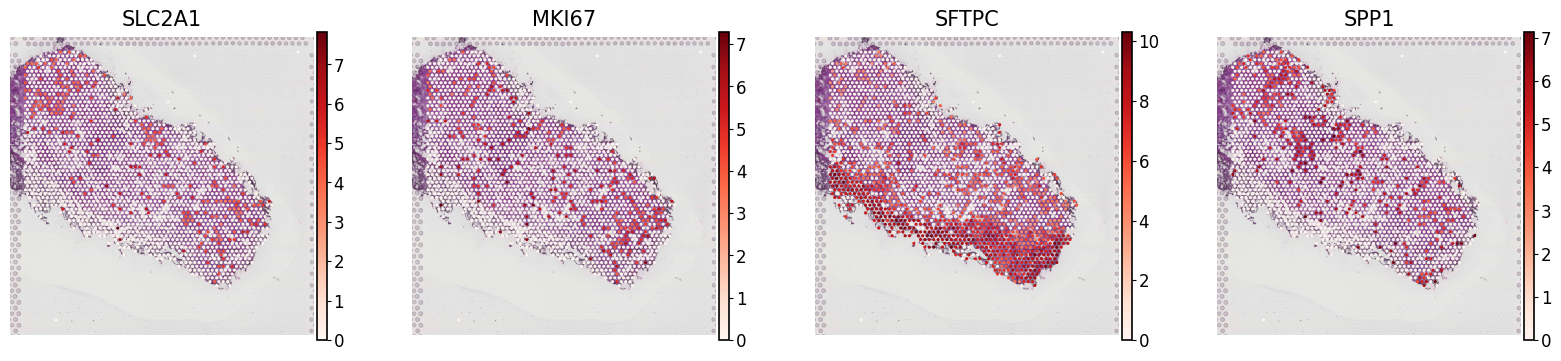

In [4]:
with mplscience.style_context():

    genes = ['SLC2A1', 'MKI67', 'SFTPC', 'SPP1']
        
    sc.pl.spatial(adata, color=genes, ncols=4, frameon=False, cmap='Reds', show=False)
    plt.savefig("./P10_T1_markers.png", dpi=300)
    plt.show()

## Compile

In [ ]:
SAMPLES = ['P10_T1', 'P10_T2', 'P10_T3', 'P10_T4',
           'P11_T1', 'P11_T2', 'P11_T3', 'P11_T4',
           'P15_T1', 'P15_T2',
           'P16_T1', 'P16_T2',
           'P17_T1', 'P17_T2',
           'P19_T1', 'P19_T2',
           'P24_T1', 'P24_T2',
           'P25_T1', 'P25_T2']

cancer_type = {'P10': 'LUAD',
               'P11': 'LUSC',
               'P15': 'LUAD',
               'P16': 'LUAD',
               'P17': 'LUSC',
               'P19': 'LUSC',
               'P24': 'LUAD',
               'P25': 'LUAD'
              }

to_merge = []
for sample in SAMPLES:
    _adata = sq.read.visium(f"../../../../stanford_mac_backup/kptc_spatial/data/DeZuani/{sample}/", counts_file=f"{sample}-filtered_feature_bc_matrix.h5")
    _adata.var_names_make_unique()

    _adata.obs['cancer_type'] = cancer_type[sample.split("_")[0]]
    _adata.obs['library_id'] = sample

    to_merge.append(_adata)

adata_all = anndata.concat(to_merge)

adata_all.write_h5ad("../../../data/DeZuani_combined_adata.h5ad")


## Analyze all

In [10]:
PATH_TO_PENG = "/path/to/peng/dataset/"
PATH_TO_DEZUANI = "/path/to/dezuani/dataset/"

In [8]:
peng_metadata = pd.read_csv(f"{PATH_TO_PENG}/PengEtal_Metadata.csv", sep=',')

import os

adatas = {}
for file_name in os.listdir(f"{PATH_TO_PENG}/h5ad"):

    library_id = file_name.split(".h5ad")[0]
    adatas[library_id] = sc.read_h5ad(f'{PATH_TO_PENG}/h5ad/{file_name}')
    

/orcd/data/ki/001/lab/jones/mgjones/miniconda3/envs/spatial-tracer/lib/python3.11/site-packages/anndata/_core/anndata.py:1825: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")
/orcd/data/ki/001/lab/jones/mgjones/miniconda3/envs/spatial-tracer/lib/python3.11/site-packages/anndata/_core/anndata.py:1825: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")
/orcd/data/ki/001/lab/jones/mgjones/miniconda3/envs/spatial-tracer/lib/python3.11/site-packages/anndata/_core/anndata.py:1825: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")
/orcd/data/ki/001/lab/jones/mgjones/miniconda3/envs/spatial-tracer/lib/python3.11/site-packages/anndata/_core/anndata.py:1825: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique

In [11]:
DeZuani_adata = sc.read_h5ad(f"{PATH_TO_DEZUANI}/DeZuani_combined_adata.h5ad")

DeZuani_adata.obs = DeZuani_adata.obs.rename(columns={'cancer_type': 'Type'})
DeZuani_adata.obs['Type'] = DeZuani_adata.obs['Type'].astype(str)

sample_col = 'library_id'

for lib_name in DeZuani_adata.obs[sample_col].unique():
    sample_adata = DeZuani_adata[DeZuani_adata.obs[sample_col] == lib_name].copy()
    unique_key = f"DeZuani_{lib_name}"
    adatas[unique_key] = sample_adata
    print(f"Added {unique_key} to adatas dictionary.")

/orcd/data/ki/001/lab/jones/mgjones/miniconda3/envs/spatial-tracer/lib/python3.11/site-packages/anndata/_core/anndata.py:1823: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


Added DeZuani_P10_T1 to adatas dictionary.
Added DeZuani_P10_T2 to adatas dictionary.
Added DeZuani_P10_T3 to adatas dictionary.
Added DeZuani_P10_T4 to adatas dictionary.
Added DeZuani_P11_T1 to adatas dictionary.
Added DeZuani_P11_T2 to adatas dictionary.
Added DeZuani_P11_T3 to adatas dictionary.
Added DeZuani_P11_T4 to adatas dictionary.
Added DeZuani_P15_T1 to adatas dictionary.
Added DeZuani_P15_T2 to adatas dictionary.
Added DeZuani_P16_T1 to adatas dictionary.
Added DeZuani_P16_T2 to adatas dictionary.
Added DeZuani_P17_T1 to adatas dictionary.
Added DeZuani_P17_T2 to adatas dictionary.
Added DeZuani_P19_T1 to adatas dictionary.
Added DeZuani_P19_T2 to adatas dictionary.
Added DeZuani_P24_T1 to adatas dictionary.
Added DeZuani_P24_T2 to adatas dictionary.
Added DeZuani_P25_T1 to adatas dictionary.
Added DeZuani_P25_T2 to adatas dictionary.


In [15]:
import numpy as np
import pandas as pd
from scipy.stats import spearmanr

TARGET = ['PKM', 'MKI67', 'C1QB', 'SPP1', 'FCGR2B', 'TGFB1', 'SNAI2', 'NKX2-1', 'B2M']
QUERY  = ['SLC2A1', 'SFTPC']

METADATA_COLS = ['Age', 'Sex', 'Ethinicity', 'Smoker', 'ID', 'Type',
                 'Greatest_Tumor_Diameter', 'PathStage_T', 'PathStage_N',
                 'PathStage_M', 'Stage', 'DriverMutations', 'DriverMutationsSimplified']

def compute_coexpression(adatas: dict, min_value=0) -> pd.DataFrame:
    to_merge = []

    for library_id, adata in adatas.items():
        print(f"Processing {library_id}...")

        available = [g for g in TARGET + QUERY if g in adata.var_names]
        missing   = [g for g in TARGET + QUERY if g not in adata.var_names]
        if missing:
            print(f"  WARNING: {missing} not found in {library_id}")


       #Checking expression and storing the gene data
        gene_data = {}
        for g in available:
            vals = adata[:, g].X.todense().A1 if hasattr(adata[:, g].X, "todense") else adata[:, g].X
            gene_data[g] = vals
            adata.obs[f"{g}_present"] = vals > min_value

        meta = {col: adata.obs[col].iloc[0] for col in METADATA_COLS if col in adata.obs.columns}

        for g1 in TARGET:
            if g1 not in available: continue
            g1_present = adata.obs[f"{g1}_present"].values
            g1_indices = np.where(g1_present)[0]

            for g2 in QUERY:
                if g2 not in available: continue
                g2_present = adata.obs[f"{g2}_present"].values
                g2_indices = np.where(g2_present)[0]

                #Jaccard Calculation
                norm_factor = max(len(g1_indices), len(g2_indices))
                union_size = len(np.union1d(g1_indices, g2_indices))
                co_occurrence = len(np.intersect1d(g1_indices, g2_indices)) / max(1, union_size)

                #Spearman Correlation Calculation
                rho, pval = spearmanr(gene_data[g1], gene_data[g2])

                if 'DeZuani' in library_id:
                    cancer_type = meta['Type']
                else:
                    cancer_type = library_id.split("_")[-1]

                row = {
                    'Gene1':    g1,
                    'Gene2':    g2,
                    'N_G1':     len(g1_indices),
                    'N_G2':     len(g2_indices),
                    'Library':  library_id,
                    'CoOccur_Jaccard': co_occurrence,
                    'Spearman_Rho':    rho,
                    'Spearman_Pval':   pval,
                    "Norm_Factor":     norm_factor,
                    'Type': cancer_type,
                    **meta,
                }
                to_merge.append(row)

    return pd.DataFrame(to_merge)


co_occurrence_all = compute_coexpression(adatas, min_value=2)
co_occurrence_all['Type'] = co_occurrence_all['Type'].str.replace(r'(\w+?)\d+$', r'\1', regex=True)
co_occurrence_all = co_occurrence_all.merge(peng_metadata[['SampleID', 'DriverMutations', 'DriverMutationsSimplified']], left_on='Library', right_on='SampleID', how='outer')


In [16]:
co_occurrence_all['Patient'] = co_occurrence_all.apply(lambda x: "_".join(x.Library.split("_")[:-1]), axis=1)

print(co_occurrence_all.groupby(['DriverMutationsSimplified']).agg({'Patient': 'nunique'}))

print(co_occurrence_all.groupby(['Type']).agg({'Patient': 'nunique'}))

                           Patient
DriverMutationsSimplified         
0                               13
ANKRD11                          1
EGFR                             8
KRAS                             3
        Patient
Type           
AAH          10
AIS          12
LUAD         30
LUSC          3
MIA           4
Normal        1


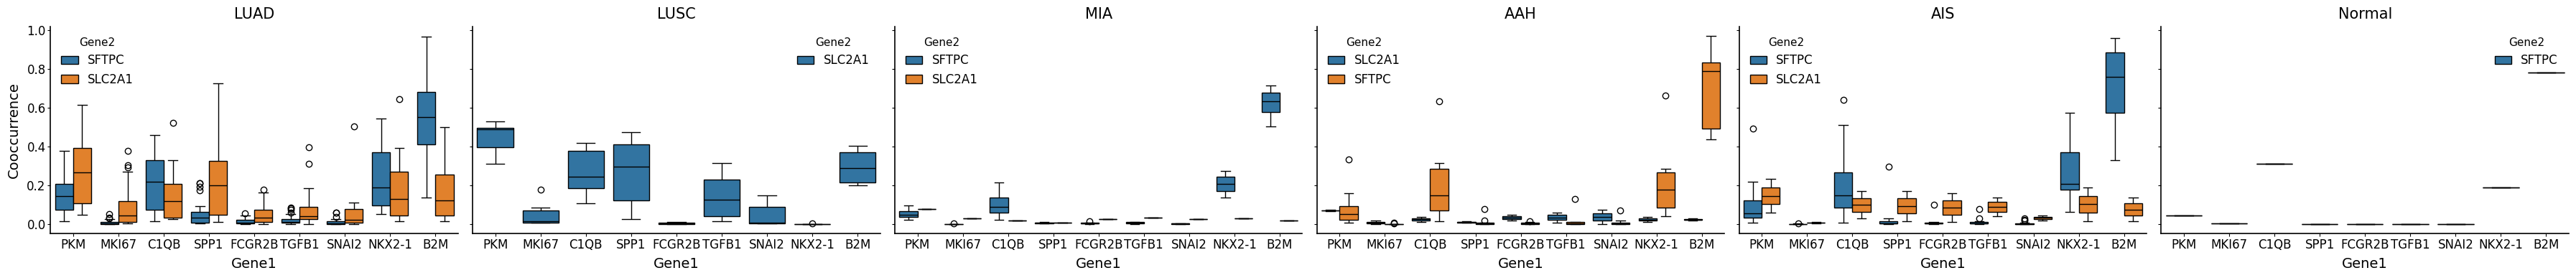

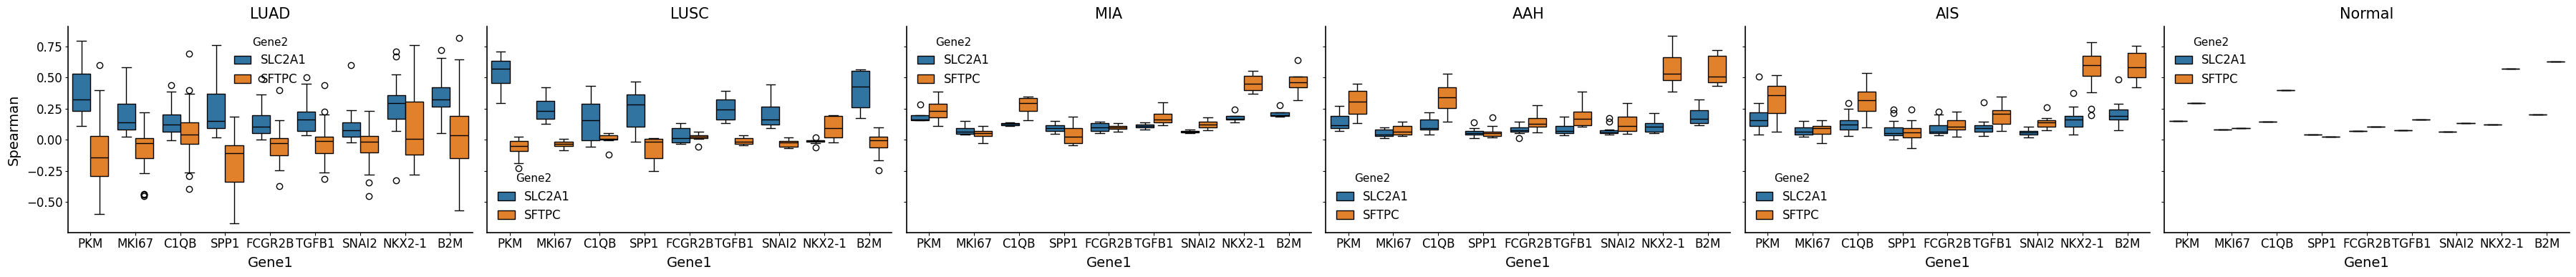

Wilcoxon [LUAD], PKM: 0.2830
Wilcoxon [LUAD], MKI67: 0.0000
Wilcoxon [LUAD], C1QB: 1.0000
Wilcoxon [LUAD], SPP1: 0.0044
Wilcoxon [LUAD], FCGR2B: 0.0001
Wilcoxon [LUAD], TGFB1: 0.0001
Wilcoxon [LUAD], SNAI2: 0.0012
Wilcoxon [LUAD], NKX2-1: 0.9977
Wilcoxon [LUAD], B2M: 1.0000


In [18]:
import mplscience
import matplotlib.pyplot as plt
import seaborn as sns

min_g2 = 100

#By Type
with mplscience.style_context():
    fig, axes = plt.subplots(1, len(co_occurrence_all['Type'].unique()),
                             figsize=(6 * len(co_occurrence_all['Type'].unique()), 4), sharey=True)

    for ax, tumor_type in zip(axes, co_occurrence_all['Type'].unique()):
        subset = co_occurrence_all[co_occurrence_all['Type'] == tumor_type]
        subset = subset[subset['N_G2'] > min_g2]
        sns.boxplot(data=subset, x='Gene1', y='CoOccur_Jaccard', hue='Gene2',
                    linecolor='black', ax=ax)
        ax.set_title(tumor_type)
        ax.set_ylabel('Cooccurrence' if ax == axes[0] else '')
        
    plt.tight_layout()
    # plt.savefig('./patient_meta_cooccurrence.pdf')
    plt.show()

    fig, axes = plt.subplots(1, len(co_occurrence_all['Type'].unique()),
                             figsize=(6 * len(co_occurrence_all['Type'].unique()), 4), sharey=True)

    for ax, tumor_type in zip(axes, co_occurrence_all['Type'].unique()):
        subset = co_occurrence_all[co_occurrence_all['Type'] == tumor_type]
        sns.boxplot(data=subset, x='Gene1', y='Spearman_Rho', hue='Gene2',
                    linecolor='black', ax=ax)
        ax.set_title(tumor_type)
        ax.set_ylabel('Spearman' if ax == axes[0] else '')

    plt.tight_layout()
    plt.show()

# Wilcoxon per tumor type
for tumor_type in co_occurrence_all['Type'].unique():
    if tumor_type == 'LUAD':
        subset = co_occurrence_all[co_occurrence_all['Type'] == tumor_type]
        for t in TARGET:
            hypox    = subset.loc[(subset['Gene1'] == t) & (subset['Gene2'] == 'SLC2A1'), 'CoOccur_Jaccard']
            alveolar = subset.loc[(subset['Gene1'] == t) & (subset['Gene2'] == 'SFTPC'),  'CoOccur_Jaccard']
            if len(hypox) > 0 and len(alveolar) > 0:
                p = scipy.stats.wilcoxon(hypox, alveolar, alternative="greater")[1]
                print(f'Wilcoxon [{tumor_type}], {t}: {p:.4f}')

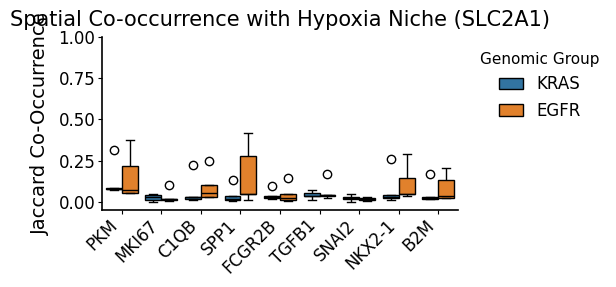

Wilcoxon [PKM]: 0.5476
Wilcoxon [MKI67]: 1.0000
Wilcoxon [C1QB]: 0.1508
Wilcoxon [SPP1]: 0.1508
Wilcoxon [FCGR2B]: 0.6905
Wilcoxon [TGFB1]: 0.8413
Wilcoxon [SNAI2]: 0.6004
Wilcoxon [NKX2-1]: 0.1508
Wilcoxon [B2M]: 0.4206


In [19]:
min_g2 = 100

driver_plot = co_occurrence_all[ (co_occurrence_all['Gene2'] == 'SLC2A1') & (co_occurrence_all['DriverMutationsSimplified'].isin(['KRAS', 'EGFR'])) ]
driver_plot = driver_plot[driver_plot['N_G2'] > min_g2]

with mplscience.style_context():
    
    fig, ax = plt.subplots(figsize=(6, 3))

    sns.boxplot(
        data=driver_plot,
        x='Gene1',
        y='CoOccur_Jaccard',
        hue='DriverMutationsSimplified',
        linecolor='black',
        hue_order=['KRAS', 'EGFR'],
        ax=ax
    )
    ax.set_ylim(-0.05, 1.0)
    ax.set_title("Spatial Co-occurrence with Hypoxia Niche (SLC2A1)")
    ax.set_ylabel("Jaccard Co-Occurrence")
    ax.set_xlabel("")

    # Rotate X-labels if you have many genes
    plt.xticks(rotation=45, ha='right')

    # Move legend to the side
    plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', title="Genomic Group")
    ax.grid(False)

    plt.tight_layout()

    plt.show()

# Wilcoxon per tumor type
for gene in driver_plot['Gene1'].unique():
    subset = driver_plot[driver_plot['Gene1'] == gene]
    kras    = subset.loc[(subset['Gene1'] == gene) & (subset['DriverMutationsSimplified'] == 'KRAS'), 'CoOccur_Jaccard'].values
    egfr = subset.loc[(subset['Gene1'] == gene) & (subset['DriverMutationsSimplified'] == 'EGFR'),  'CoOccur_Jaccard'].values
    if len(kras) > 0 and len(egfr) > 0:
        p = scipy.stats.mannwhitneyu(kras, egfr, alternative="two-sided")[1]
        print(f'Wilcoxon [{gene}]: {p:.4f}')

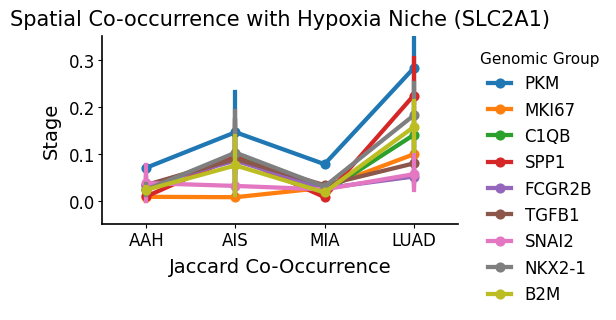

In [20]:
min_g2 = 100

stage_plot = co_occurrence_all[ (co_occurrence_all['Gene2'] == 'SLC2A1') & (co_occurrence_all['Type'].isin(['LUAD', 'AAH', 'MIA', 'AIS'])) ]
stage_plot = stage_plot[stage_plot['N_G2'] > min_g2]

my_order = ['AAH', 'AIS', 'MIA', 'LUAD']

with mplscience.style_context():
    
    fig, ax = plt.subplots(figsize=(6, 3))

    sns.pointplot(
        data=stage_plot,
        x='Type',
        y='CoOccur_Jaccard',
        hue='Gene1',
        order=my_order,
        markersize=5,
        ax=ax)

    ax.set_ylim(-0.05, 0.35)
    ax.set_title("Spatial Co-occurrence with Hypoxia Niche (SLC2A1)")
    ax.set_xlabel("Jaccard Co-Occurrence")
    ax.set_ylabel("Stage")

    # Rotate X-labels if you have many genes
    # plt.xticks(rotation=45, ha='right')

    # Move legend to the side
    plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', title="Genomic Group")
    ax.grid(False)

    plt.tight_layout()

    plt.show()
